In [1]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
dir_s2 = Path("out") / "study2"
ls_meta = [f for f in dir_s2.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])

# since the first two iterations of rtdetr-l are not comparable to the others, we remove them
data = data.query("(model == 'rtdetr-l' and iters > 2) or (model != 'rtdetr-l')")
data.loc[data['model'] == 'rtdetr-l', 'iters'] -= 2
data = data.query("iters <= 6") 

# add strategy category
data["cat"] = "X"  # default category
data.loc[data.is_finetune == "1_NOFT", "cat"] = "A_unfinetuned"
data.loc[data.is_finetune == "2_FT", "cat"] = "B_finetuned_unsupervised"
data.loc[data.metric == "map", "cat"] = "C_finetuned_supervised"
data.to_csv("out/s2_raw.csv", index=False)

# order
strategy_order = [
    "bo_exploitation",
    "bo_exploration", 
    "grid_search", 
]
cat_order = [
    "A_unfinetuned",
    "B_finetuned_unsupervised",
    "C_finetuned_supervised"
]
model_order = ["yolo11n", "yolo11m", "rtdetr-l"]

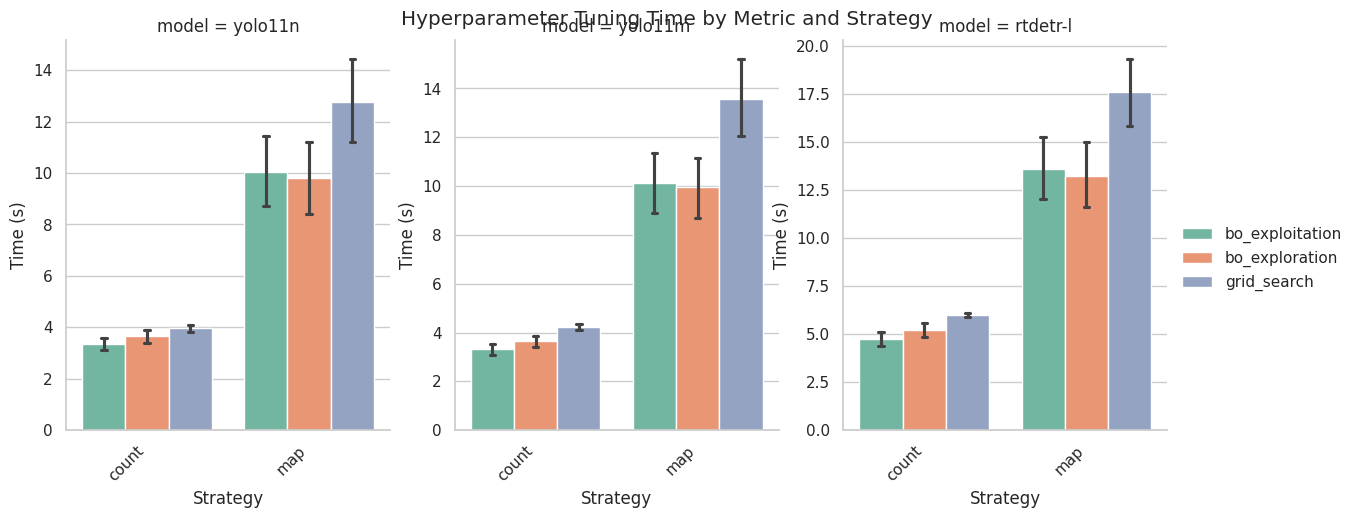

In [2]:
# box plot: x metric, hue: strategy, y time_hptuning
sns.set_theme(style="whitegrid")
data_hptime = data.query("metric != 'baseline' and time_hptuning < 40")

# col_facet by metric, x=strategy, y time_hptuning,
g = sns.FacetGrid(data_hptime, 
    col='model',
    sharey=False,
    height=5, aspect=.8)
g.map_dataframe(sns.barplot,
    x='metric', y='time_hptuning',
    hue='strategy', hue_order=strategy_order,
    width=0.8,
    # add caps to the error bars
    capsize=.1,
    palette="Set2",
    data=data_hptime)

g.add_legend()
g.fig.suptitle('Hyperparameter Tuning Time by Metric and Strategy')
for ax in g.axes.flat:
    ax.set_xlabel('Strategy')
    ax.set_ylabel('Time (s)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
g.savefig("out/s2_time_hptuning.png", dpi=300)

In [ ]:
# test hukey hsd between three groups
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

data_hptime_agg = data_hptime.groupby(['model', 'metric', 'strategy']).agg(
    time_hptuning_mean=('time_hptuning', 'mean'),
    time_hptuning_std=('time_hptuning', 'std'),
    time_hptuning_count=('time_hptuning', 'count')
).reset_index(inplace=False)
data_hptime_agg.to_csv("out/s2_time_hptuning.csv", index=False)

for m in model_order:
    for s in ["count", "map"]:
        print("model:", m, "opt-metric", s)
        data_tmp = data_hptime.query("model == @m and metric == @s")
        model = ols('time_hptuning ~ C(strategy)', data=data_tmp).fit()
        anova_results = anova_lm(model, typ=2)
        if anova_results['PR(>F)'][0] < 0.05:
            print("*")
            tukey = pairwise_tukeyhsd(data_tmp.loc[:, 'time_hptuning'].values, 
                                      data_tmp.loc[:, 'strategy'].values)
            # print(tukey)
            for group1, group2, pvalue in zip(tukey.groupsunique[:-1], tukey.groupsunique[1:], tukey.pvalues):
                if pvalue < 0.05:
                    print(f"{group1} vs {group2}: DIFFERENT!")
                else:
                    print(f"{group1} vs {group2}: SIMILAR")
        else:
            print("NS")

# yolo11n, count:  a, a, b
# yolo11n, map:    a, a, b
# yolo11m, count:  a, b, c
# yolo11m, map:    a, a, b    
# rtdetr-l, count: a, a, b
# rtdetr-l, map::  a, a, b

model: yolo11n opt-metric count
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: yolo11n opt-metric map


*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: yolo11m opt-metric count
*


bo_exploitation vs bo_exploration: DIFFERENT!
bo_exploration vs grid_search: DIFFERENT!
model: yolo11m opt-metric map
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: rtdetr-l opt-metric count
*


bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!
model: rtdetr-l opt-metric map
*
bo_exploitation vs bo_exploration: SIMILAR
bo_exploration vs grid_search: DIFFERENT!


In [13]:
# calculate mean, median, std, min, max
data_sum = data.\
    query("iters <= 5").\
    groupby(['model', "cat", "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
    # map50
    map50_mean=pd.NamedAgg(column='map50', aggfunc='mean'),
    map50_std=pd.NamedAgg(column='map50', aggfunc='std'),
    # precision
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    # recall
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    # f1
    f1_mean=pd.NamedAgg(column='f1', aggfunc='mean'),
    f1_std=pd.NamedAgg(column='f1', aggfunc='std'),
    # time_hptuning'
    time_hptuning_mean=pd.NamedAgg(column='time_hptuning', aggfunc='mean'),
    time_hptuning_std=pd.NamedAgg(column='time_hptuning', aggfunc='std'),
    # time_inference
    time_inference_mean=pd.NamedAgg(column='time_inference', aggfunc='mean'),
    time_inference_std=pd.NamedAgg(column='time_inference', aggfunc='std'),
).reset_index()
data_sum.to_csv(Path("out") / "s2_pivot.csv", index=False)
data_sum

,model,cat,strategy,n_obs,map50_mean,map50_std,pre_mean,pre_std,rec_mean,rec_std,f1_mean,f1_std,time_hptuning_mean,time_hptuning_std,time_inference_mean,time_inference_std
0,rtdetr-l,A_unfinetuned,baseline,50,0.001230,0.001077,0.002540,0.002139,0.000242,0.000223,0.000452,0.000392,0.000000,0.000000,4.533600,0.278647
1,rtdetr-l,A_unfinetuned,bo_exploitation,46,0.531539,0.181087,0.649072,0.207987,0.511530,0.182843,0.570552,0.194216,5.245435,2.288230,63.942391,33.921261
2,rtdetr-l,A_unfinetuned,bo_exploration,46,0.553461,0.184023,0.661698,0.211054,0.543135,0.183827,0.595730,0.196624,5.011304,1.791510,70.154565,35.295768
3,rtdetr-l,A_unfinetuned,grid_search,46,0.642424,0.036983,0.753948,0.030254,0.643120,0.020150,0.694059,0.023713,5.966304,0.531494,112.472826,2.353405
4,rtdetr-l,B_finetuned_unsupervised,baseline,50,0.002602,0.003571,0.005248,0.007090,0.000570,0.001004,0.001014,0.001745,0.000000,0.000000,4.505400,0.548420
5,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,48,0.534123,0.223122,0.638800,0.248048,0.504792,0.216168,0.561540,0.230825,4.310833,1.790186,53.716250,33.412046
6,rtdetr-l,B_finetuned_unsupervised,bo_exploration,48,0.592858,0.180329,0.698367,0.194415,0.567404,0.170672,0.625173,0.181536,5.031458,1.832540,70.819583,33.827209
7,rtdetr-l,B_finetuned_unsupervised,grid_search,48,0.668450,0.068427,0.772448,0.050111,0.656494,0.040634,0.709694,0.044304,6.007917,0.534610,112.061875,2.929776
8,rtdetr-l,C_finetuned_supervised,bo_exploitation,45,0.597169,0.156537,0.705198,0.162355,0.566040,0.152536,0.626196,0.158748,13.441333,5.279844,47.962889,21.824403
9,rtdetr-l,C_finetuned_supervised,bo_exploration,46,0.624754,0.127312,0.729354,0.127634,0.599378,0.119432,0.656863,0.123034,13.160435,6.181290,44.974783,15.351474


In [14]:
data_fig = data.melt(id_vars=["model", "cat", "strategy", "divider", "overlap"], 
                     var_name="met", value_name="score")
data_fig = data_fig.query("met in ['precision', 'recall', 'f1', 'map50', 'time_inference']")
data_fig

,model,cat,strategy,divider,overlap,met,score
14816,yolo11n,A_unfinetuned,baseline,0.0,0.00,time_inference,4.53
14817,yolo11n,A_unfinetuned,bo_exploration,4.0,0.62,time_inference,73.69
14818,yolo11n,A_unfinetuned,bo_exploitation,2.0,0.53,time_inference,35.69
14819,yolo11n,A_unfinetuned,grid_search,4.0,0.50,time_inference,73.31
14820,yolo11n,B_finetuned_unsupervised,baseline,0.0,0.00,time_inference,2.89
...,...,...,...,...,...,...,...
25923,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,4.0,0.00,f1,0.6736
25924,rtdetr-l,B_finetuned_unsupervised,grid_search,4.0,0.50,f1,0.6855
25925,rtdetr-l,C_finetuned_supervised,bo_exploration,4.0,0.05,f1,0.6736
25926,rtdetr-l,C_finetuned_supervised,bo_exploitation,2.0,0.09,f1,0.4624


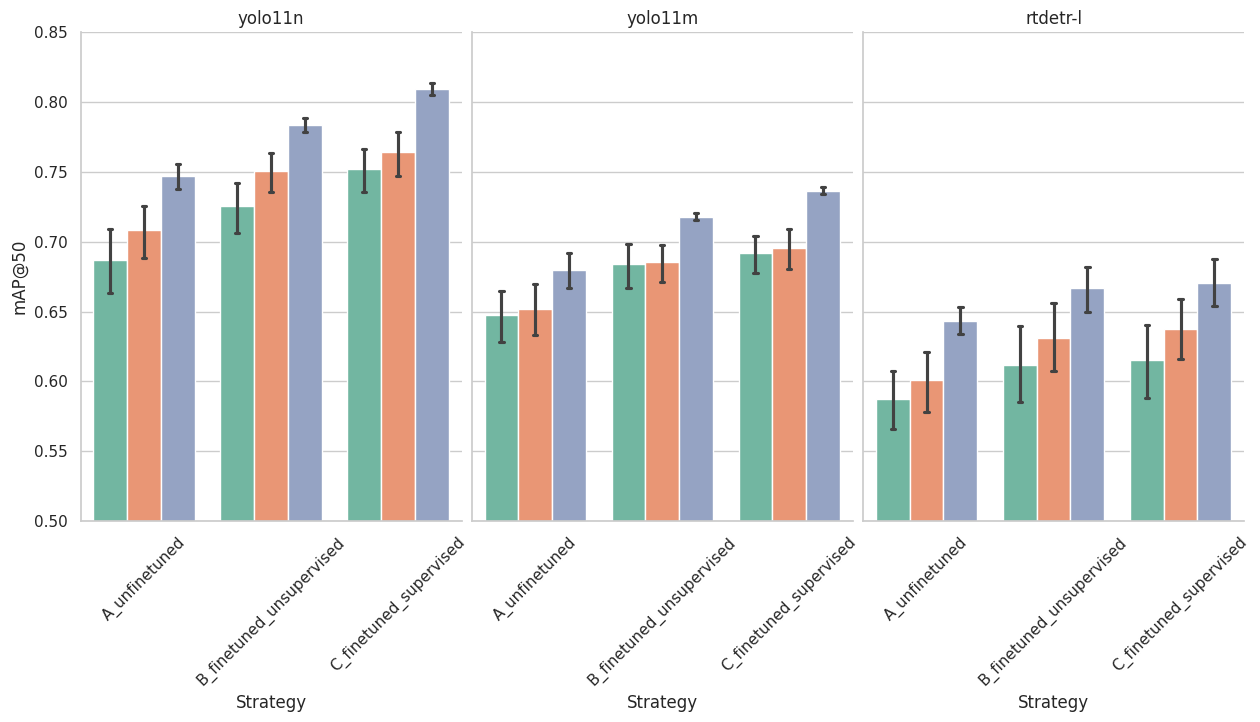

In [33]:
sns.set_theme(style="whitegrid")

# set cat order for data_fig
data_fig["cat"] = pd.Categorical(data_fig["cat"], categories=cat_order, ordered=True)
g = sns.FacetGrid(
    data_fig.query("met == 'map50' and\
        strategy != 'baseline' and\
        score > 0.2"),
    col="model",
    col_order=model_order,
    sharey=True,
    height=6, aspect=1.2,
)
g.map_dataframe(sns.barplot, 
    # x="strategy", y="score",
    x="cat", y="score", 
    # hue="cat", hue_order=cat_order,
    capsize=.1,
    hue="strategy", hue_order=strategy_order,
    palette="Set2",
    )
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
g.set(
    ylim=(.5, .85),
    xlabel="Strategy",
    ylabel="mAP@50",
)
#     xscale="log",
#     xticks=[2**i for i in range(6, 11)],
#     xticklabels=[2**i for i in range(6, 11)],
#     xlabel="Number of training images (n)",)

# set x label 45 degrees
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45)
g.figure.subplots_adjust(right=1.2)
g.figure.set_size_inches(10, 6)
g.savefig(Path("out") / "s2_results.png", dpi=300)

data_fig.to_csv(Path("out") / "s2_results.csv", index=False)

In [22]:
for m in model_order:
    print("model:", m)
    data_tmp = data_fig.query("model == @m and\
        met == 'map50' and\
            strategy == 'grid_search'")
    data_tmp['score'] = data_tmp['score'].astype(float)
    model = ols('score ~ C(cat)', data=data_tmp).fit()
    anova_results = anova_lm(model, typ=2)
    if anova_results['PR(>F)'][0] < 0.05:
        print("*")
        tukey = pairwise_tukeyhsd(data_tmp.loc[:, 'score'].values, 
                                  data_tmp.loc[:, 'cat'].values)
        print(tukey)
        for group1, group2, pvalue in zip(tukey.groupsunique[:-1], tukey.groupsunique[1:], tukey.pvalues):
            if pvalue < 0.05:
                print(f"{group1} vs {group2}: DIFFERENT!")
            else:
                print(f"{group1} vs {group2}: SIMILAR")
    else:
        print("NS")
# yolo11n: a, b, c
# yolo11m: a, b, c
# rtdetr-l: a, ab, b
            

model: yolo11n
*
                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
         group1                   group2          meandiff p-adj lower  upper  reject
-------------------------------------------------------------------------------------
           A_unfinetuned B_finetuned_unsupervised   0.0366   0.0 0.0256 0.0477   True
           A_unfinetuned   C_finetuned_supervised   0.0624   0.0 0.0511 0.0737   True
B_finetuned_unsupervised   C_finetuned_supervised   0.0258   0.0 0.0144 0.0371   True
-------------------------------------------------------------------------------------
A_unfinetuned vs B_finetuned_unsupervised: DIFFERENT!
B_finetuned_unsupervised vs C_finetuned_supervised: DIFFERENT!
model: yolo11m
*


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                   group2          meandiff p-adj  lower  upper  reject
--------------------------------------------------------------------------------------
           A_unfinetuned B_finetuned_unsupervised   0.0382    0.0 0.0251 0.0513   True
           A_unfinetuned   C_finetuned_supervised    0.057    0.0 0.0435 0.0704   True
B_finetuned_unsupervised   C_finetuned_supervised   0.0188 0.0028 0.0055  0.032   True
--------------------------------------------------------------------------------------
A_unfinetuned vs B_finetuned_unsupervised: DIFFERENT!
B_finetuned_unsupervised vs C_finetuned_supervised: DIFFERENT!
model: rtdetr-l
*
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                   group2          meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------------

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [4]:
import pandas as pd
import numpy as np
data_fig = pd.read_csv("out/s2_results.csv")
data_grid_all = data_fig.query("met in ['map50', 'time_inference']").\
                   query("strategy != 'baseline'").\
                       query("cat != 'A_unfinetuned'").\
                          query("model == 'yolo11n'")
# -0.125, 0.125 -> 0
# 0.125, 0.375 -> 0.25
# 0.375, 0.625 -> 0.5
def convert_overlap(overlap):
    if overlap < 0.125:
        return 0
    elif overlap < 0.375:
        return 0.25
    elif overlap < 0.625:
        return 0.5
def convert_divider(divider):
    return round(divider)
data_grid_all['overlap_cat'] = data_grid_all['overlap'].apply(convert_overlap)
data_grid_all['divider_cat'] = data_grid_all['divider'].apply(convert_divider)
data_grid_all


,model,cat,strategy,divider,overlap,met,score,overlap_cat,divider_cat
5,yolo11n,B_finetuned_unsupervised,bo_exploration,3.0,0.34,time_inference,30.0000,0.25,3
6,yolo11n,B_finetuned_unsupervised,bo_exploitation,2.0,0.62,time_inference,32.3900,0.50,2
7,yolo11n,B_finetuned_unsupervised,grid_search,4.0,0.50,time_inference,66.3000,0.50,4
8,yolo11n,C_finetuned_supervised,bo_exploration,4.0,-0.12,time_inference,26.6100,0.00,4
9,yolo11n,C_finetuned_supervised,bo_exploitation,3.0,0.29,time_inference,29.6400,0.25,3
...,...,...,...,...,...,...,...,...,...
3655,yolo11n,B_finetuned_unsupervised,bo_exploitation,3.0,0.52,map50,0.7523,0.50,3
3656,yolo11n,B_finetuned_unsupervised,grid_search,4.0,0.50,map50,0.7937,0.50,4
3657,yolo11n,C_finetuned_supervised,bo_exploration,3.0,-0.05,map50,0.7478,0.00,3
3658,yolo11n,C_finetuned_supervised,bo_exploitation,3.0,0.35,map50,0.7554,0.25,3


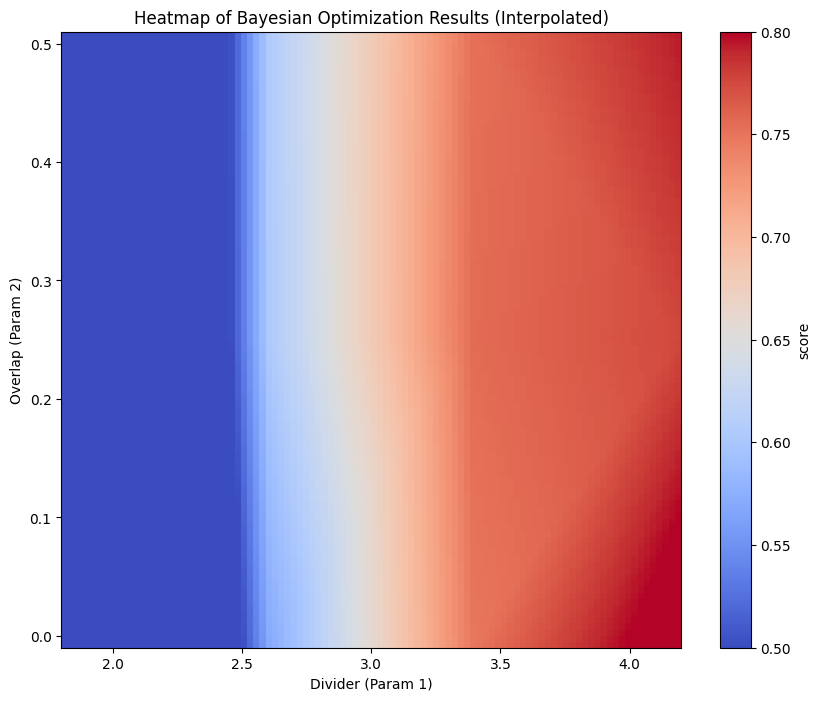

In [7]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

def plot_hpmap(data_grid, crange=(0.6, 0.9), x_jitter=.03):
    # Prepare data for interpolation
    x = data_grid["divider_cat"].values
    y = data_grid["overlap_cat"].values
    z = data_grid["score"].values
    s = data_grid["strategy"].values

    # Create a regular grid for interpolation
    grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]

    # Interpolate the data
    grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(
        grid_z.T,
        # extent=(min(x), max(x), min(y), max(y)),
        extent=(1.8, 4.2, -0.01, 0.51),
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
    )
    plt.colorbar(label="score")
    # set uplimits of hue
    plt.clim(*crange)
    plt.xlabel("Divider (Param 1)")
    plt.ylabel("Overlap (Param 2)")
    plt.title("Heatmap of Bayesian Optimization Results (Interpolated)")
    
    # df_b = data_grid[data_grid["cat"] == "B_finetuned_unsupervised"]
    # df_b = data_grid[data_grid["strategy"] == "grid_search"]
    # df_b = df_b.sort_values(by="score", ascending=False)
    # # print(df_b)
    # df_c = data_grid[data_grid["cat"] == "C_finetuned_supervised"]
    # df_c = data_grid[data_grid["strategy"] == "grid_search"]
    # df_c = df_c.sort_values(by="score", ascending=False)
    # # print(df_c)
    # plt.scatter(df_b["divider"] + x_jitter, df_b["overlap"],
    #             color="blue", marker="o", label="bo_exploration", s=100, edgecolors='black')
    # plt.scatter(df_c["divider"] - x_jitter, df_c["overlap"],
    #             color="white", marker="X", label="grid_search", s=100, edgecolors='black')
    # plt.legend()
    return plt, grid_z
plot, grid_map = plot_hpmap(data_grid_all.query("met == 'map50' and model == 'yolo11n'"), (0.5, 0.80))
plot.savefig("out/s2_hpmap_map50.png", dpi=300)


In [9]:
data_grid_all.query("model == 'yolo11n' and cat == 'C_finetuned_supervised' and met == 'map50'").\
    groupby(["strategy", "overlap_cat", "divider_cat"]).agg(
    n_obs=pd.NamedAgg(column='score', aggfunc='count'),
    score_mean=pd.NamedAgg(column='score', aggfunc='mean'),
    score_std=pd.NamedAgg(column='score', aggfunc='std'),
).reset_index(inplace=False).dropna().\
    pivot(index=["overlap_cat", "divider_cat"], 
          columns="strategy", 
          values=["n_obs", "score_mean", "score_std"]).\
    reset_index(inplace=False).to_csv("out/s2_hpmap.csv", index=False)

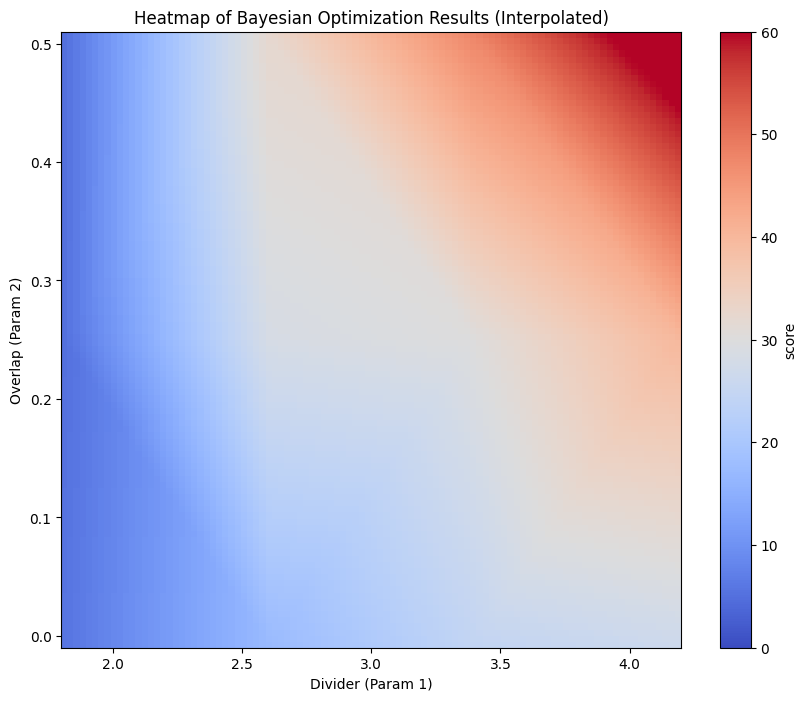

In [12]:
plot, grid_time = plot_hpmap(data_grid_all.query("met == 'time_inference' and model == 'yolo11n'"), (0, 60))
plot.savefig("out/s2_hpmap_infer.png", dpi=300)

In [20]:
ls_grid = []
ls_overlap = []
ls_map = []
ls_time = []
for i in [1, 2, 3, 4]:
    for j in [0, 0.25, 0.5]:
        # 1-> 0, 2-> 33, 3-> 66, 4-> 100
        idx_i = int((i - 1) * 100 / 3)
        idx_j = int(j * 100 * 2)
        idx_i = min(idx_i, grid_map.shape[0] - 1)
        idx_j = min(idx_j, grid_map.shape[1] - 1)
        ls_grid.append(i)
        ls_overlap.append(j)
        ls_map.append(grid_map[idx_i, idx_j])
        ls_time.append(grid_time[idx_i, idx_j])
df_grid = pd.DataFrame({
    "divider": ls_grid,
    "overlap": ls_overlap,
    "map50": ls_map,
    "time_inference": ls_time
})
df_grid.to_csv("out/s2_hpmap_exp.csv", index=False)